In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from skimage.io import imsave
from os.path import join
from skimage.io import imread
from skimage.filters import threshold_triangle
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_dilation
from skimage.feature import peak_local_max

Loaded array has shape: (2048, 2048, 4)


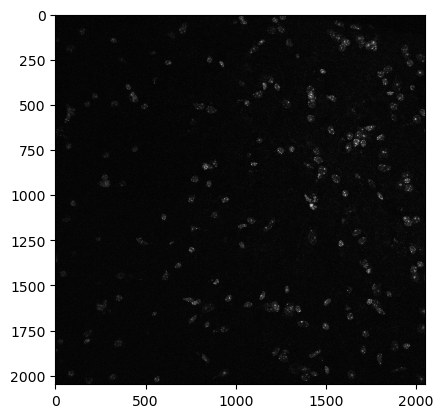

In [3]:
dirpath = r'E:\ND2\tiff'
#filename = r'P46_SC_107_1_40X_loc06.tif'
filename =r'C66_SC_101_2_40X_loc01.tif'
filepath = join(dirpath,filename)
img = imread(filepath)
print("Loaded array has shape:", img.shape)

# Extract individual channels
img1 = img[:, :, 0]  # Channel 1
img2 = img[:, :, 1]  # Channel 2
img3 = img[:, :, 2]  # Channel 3
img4 = img[:, :, 3]  # Channel 4

# Display raw channels
plt.imshow(img4, interpolation='none', cmap='gray')

Text(0.5, 1.0, 'Membrane Mask')

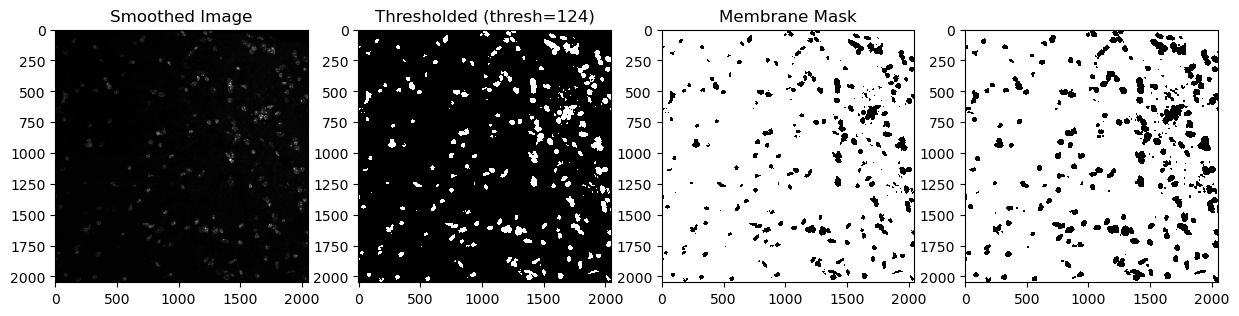

In [4]:
from skimage.filters import threshold_triangle
img_smooth = ndi.gaussian_filter(img4, sigma=2)

# Automatically find the best threshold
thresh = threshold_triangle(img_smooth)
mem = img_smooth > thresh
mem_holefilled = ~ndi.binary_fill_holes(mem)  # Short form

i = 10
SE = (np.mgrid[:i,:i][0] - np.floor(i/2))**2 + (np.mgrid[:i,:i][1] - np.floor(i/2))**2 <= np.floor(i/2)**2
pad_size = i + 1
mem_inv = ~mem_holefilled
mem_padded = np.pad(mem_inv, pad_size, mode='reflect')
mem_dilated = binary_dilation(mem_padded, structure=SE)
mem_filled = ndi.binary_fill_holes(mem_dilated)
mem_final = ~mem_filled[pad_size:-pad_size, pad_size:-pad_size]

fig, ax = plt.subplots(1, 4, figsize=(15,15))
ax[0].imshow(img_smooth, interpolation='none', cmap='gray')
ax[1].imshow(mem, interpolation='none', cmap='gray')
ax[2].imshow(mem_holefilled, interpolation='none', cmap='gray')
ax[3].imshow(mem_final, cmap='gray', interpolation='none')
ax[0].set_title('Smoothed Image')
ax[1].set_title(f'Thresholded (thresh={thresh:.0f})')
ax[2].set_title('Membrane Mask')

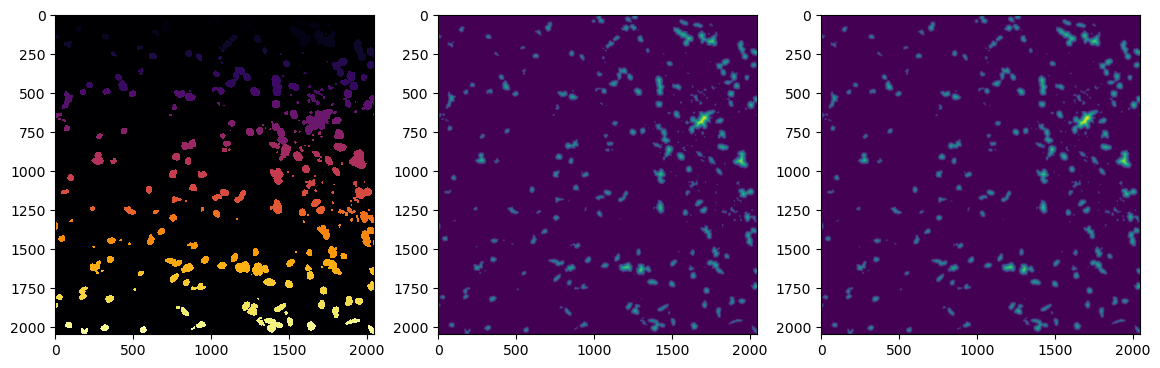

In [5]:
cell_labels, _ = ndi.label(~mem_final)

dist_trans = ndi.distance_transform_edt(~mem_final)
dist_trans_smooth = ndi.gaussian_filter(dist_trans, sigma=2)

fig, ax = plt.subplots(1, 3, figsize=(14, 14))
ax[0].imshow(cell_labels, interpolation='none', cmap='inferno')
ax[1].imshow(dist_trans, interpolation='none', cmap='viridis')
ax[2].imshow(dist_trans_smooth, interpolation='none', cmap='viridis')

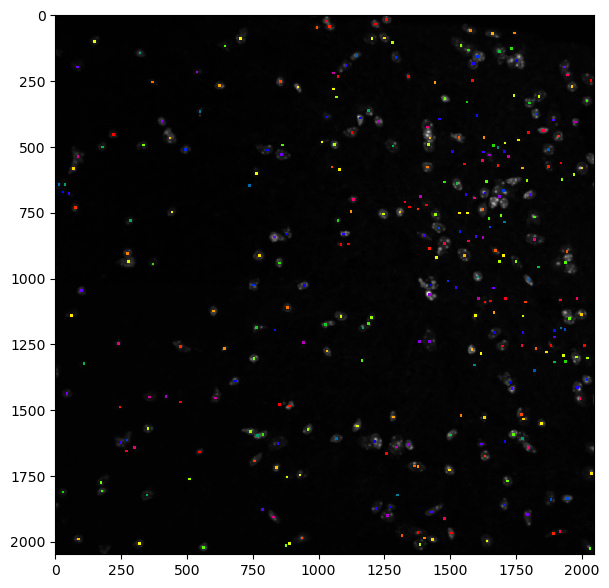

In [6]:
seed_coords = peak_local_max(dist_trans_smooth, min_distance=10)
seeds = np.zeros_like(dist_trans_smooth, dtype=bool)
seeds[tuple(seed_coords.T)] = True
seeds_dil = ndi.maximum_filter(seeds, size=10)

seeds_labeled = ndi.label(seeds)[0]
seeds_labeled_dil = ndi.maximum_filter(seeds_labeled, size=10)  # Expand a bit for visualization

fig, ax = plt.subplots(figsize=(7,7))
plt.imshow(img_smooth, interpolation='none', cmap='gray')
plt.imshow(np.ma.array(seeds_labeled_dil, mask=seeds_labeled_dil==0), interpolation='none', cmap='prism')

In [ ]:
from skimage.segmentation import watershed
ws = watershed(-dist_trans_smooth, seeds_labeled, mask=~mem_final)
fig, ax = plt.subplots(1, 2, figsize=(14, 14))
ax[0].imshow(img_smooth, interpolation='none', cmap='gray')
ax[0].imshow(np.ma.array(seeds_labeled_dil, mask=seeds_labeled_dil==0), interpolation='none', cmap='prism')

#ax[1].imshow(img_smooth, interpolation='none', cmap='gray')
ax[1].imshow(ws, interpolation='none', cmap='prism')
plt.show()

In [ ]:
#Remove cells at the border
border_mask = np.zeros(ws.shape, dtype=bool)
border_mask = ndi.binary_dilation(border_mask, border_value=1)
clean_ws = np.copy(ws)

for cell_ID in np.unique(ws):
    cell_mask = ws==cell_ID 
    cell_border_overlap = np.logical_and(cell_mask, border_mask)  # Overlap of cell mask and boundary mask
    total_overlap_pixels = np.sum(cell_border_overlap)            # Sum overlapping pixels
    if total_overlap_pixels > 0: 
        clean_ws[cell_mask] = 0

# Collect cell areas
results = {"cell_id": [], "cell_area": []}
for cell_ID in np.unique(clean_ws)[1:]:
    results["cell_id"].append(cell_ID)
    results["cell_area"].append(np.sum(clean_ws == cell_ID))

In [ ]:
# Filter by size
min_cell_size = 500
max_cell_size = 6000
prev_count = len(results['cell_id'])
valid_ids = [cid for cid, area in zip(results['cell_id'], results['cell_area'])
             if min_cell_size < area < max_cell_size]

# Apply filter and relabel
clean_ws2 = np.zeros_like(clean_ws)
for new_id, old_id in enumerate(valid_ids, start=1):
    clean_ws2[clean_ws == old_id] = new_id
    
new_count = len(valid_ids)
print(f"Previous cell count: {prev_count}")
print(f"New cell count:      {new_count}")

fig, ax = plt.subplots(1, 3, figsize=(14, 14))
ax[0].imshow(img_smooth, interpolation='none', cmap='gray')
ax[1].imshow(np.zeros_like(clean_ws), cmap='gray', vmin=0, vmax=1)
ax[1].imshow(np.ma.array(clean_ws, mask=clean_ws==0), interpolation='none', cmap='prism')
ax[2].imshow(np.zeros_like(clean_ws2), cmap='gray', vmin=0, vmax=1)
ax[2].imshow(np.ma.array(clean_ws2, mask=clean_ws2==0), interpolation='none', cmap='prism')
plt.show()

In [ ]:
edges = np.zeros_like(clean_ws2)
for cell_ID in np.unique(clean_ws2)[1:]:
    cell_mask = clean_ws2==cell_ID
    eroded_cell_mask = ndi.binary_erosion(cell_mask, iterations=5) # Increase iterations to make boundary wider!
    edge_mask = np.logical_xor(cell_mask, eroded_cell_mask)
    edges[edge_mask] = cell_ID

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 14))
ax[0].imshow(img_smooth, interpolation='none', cmap='gray')
ax[1].imshow(np.zeros_like(edges), cmap='gray', vmin=0, vmax=1)  
ax[1].imshow(np.ma.array(edges, mask=edges==0), interpolation='none', cmap='prism')

In [1]:
#Final_fig
fig = plt.figure(figsize=(18, 18))
fig.patch.set_facecolor('black')

# Redefine cleanly using gridspec
gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05)

grid_positions = {
    'center': (1, 1),
    1: (0, 0),
    2: (0, 1),
    3: (0, 2),
    4: (1, 2),
    5: (2, 2),
    6: (2, 1),
    7: (2, 0),
    8: (1, 0),
}

label_color = '#99ccff'  # light blue

def add_panel(ax, image, title_num=None, cmap='gray', vmin=None, vmax=None,
              overlay=None, overlay_cmap='prism', extra_text=None):
    ax.set_facecolor('black')
    ax.imshow(image, interpolation='none', cmap=cmap, vmin=vmin, vmax=vmax)
    if overlay is not None:
        ax.imshow(np.ma.array(overlay, mask=overlay==0), interpolation='none', cmap=overlay_cmap)
    if title_num is not None:
        ax.text(0.02, 0.98, f'{title_num}', transform=ax.transAxes,
                fontsize=16, color=label_color, fontweight='bold', va='top', ha='left')
    if extra_text is not None:
        ax.text(0.98, 0.98, extra_text, transform=ax.transAxes,
                fontsize=12, color='white', va='top', ha='right')
    ax.axis('off')

# Center: raw image
ax_c = fig.add_subplot(gs[1, 1])
ax_c.imshow(img4, interpolation='none')
ax_c.text(0.5, 0.98, 'RAW', transform=ax_c.transAxes,
          fontsize=14, color='white', va='top', ha='center', fontweight='bold')
ax_c.axis('off')

# 1: img_smooth (gaussian blur)
ax1 = fig.add_subplot(gs[grid_positions[1]])
add_panel(ax1, img_smooth, title_num=1, cmap='gray', vmin=0, vmax=500)
# 2: mem
ax2 = fig.add_subplot(gs[grid_positions[2]])
add_panel(ax2, mem, title_num=2, cmap='gray')
# 3: mem_holefilled
ax3 = fig.add_subplot(gs[grid_positions[3]])
add_panel(ax3, mem_holefilled, title_num=3, cmap='gray')
# 4: cell_labels
ax4 = fig.add_subplot(gs[grid_positions[4]])
add_panel(ax4, cell_labels, title_num=4, cmap='inferno')
# 5: dist_trans_smooth
ax5 = fig.add_subplot(gs[grid_positions[5]])
add_panel(ax5, dist_trans_smooth, title_num=5, cmap='viridis')
# 6: seeds_labeled_clean with img_smooth background + cell count
ax6 = fig.add_subplot(gs[grid_positions[6]])
add_panel(ax6, img_smooth, title_num=6, cmap='gray', overlay=seeds_labeled_dil, overlay_cmap='prism')
# 7: watershed
ax7 = fig.add_subplot(gs[grid_positions[7]])
add_panel(ax7, np.zeros_like(clean_ws2), cmap='gray', title_num=7, overlay=ws, overlay_cmap='prism')
# 8: edges
ax8 = fig.add_subplot(gs[grid_positions[8]])
add_panel(ax8, img_smooth, title_num=8, cmap='gray',
          overlay=edges, overlay_cmap='prism',
          extra_text=f'Cells: {new_count}')

plt.suptitle('Segmentation Pipeline', color='white', fontsize=20, fontweight='bold', y=0.995)
plt.savefig('pipeline_overview.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

NameError: name 'np' is not defined